# 多元导数与链式法则实验

## 目标
同一两参数模型的手算、求和、展开、Jacobian链式与有限差分互相核对，再检查分支、方向、定义域和形状。

已核验主点结果：损失19/48，梯度(-1/6,-5/6)，预测Jacobian形状3×2，单位方向(3/5,4/5)的变化率-23/30。共享节点例的梯度为(5,2)。

## 准备
直接先修第9至10讲与第13讲；不使用自动微分框架。将本文件、experiment.py与data文件夹放在一起，先读lab.md，然后重启内核并运行全部单元。Python 3.12、NumPy 2.3.5、Matplotlib与Jupyter/IPython足够；实验本身离线、无随机数、无付费服务。

定义域与数据：主模型p_i=a*x_i+b²在整个实参数平面有定义；固定3条合成记录，残差为预测减目标。浮点数范围有限，数值检查不是一般证明。

In [1]:
from pathlib import Path
import sys
import io
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image
import experiment as e

np.set_printoptions(precision=9, suppress=True)
print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("必需文件存在:", all(Path(f).exists() for f in ["experiment.py", "data/observations.csv"]))

def show_figure(fig):
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=130, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

Python: 3.12.14
NumPy: 2.3.5
必需文件存在: True


## 1 纸笔基准与读取数据
先在纸上算b²、预测、残差及平方平均，再执行。Fraction保留精确分数；这里的x、y是求导时固定的数据。

In [2]:
x, y = e.load_data()
theta = np.array([1., 0.5])
print("固定输入:", x)
print("固定目标:", y)
print("参数 a,b:", theta)
print("精确手算核验:", e.exact_hand())
p = e.prediction(theta, x)
print("预测:", p)
print("残差:", p-y)
print("损失:", e.loss(theta, x, y))

固定输入: [0. 1. 2.]
固定目标: [1. 2. 2.]
参数 a,b: [1.  0.5]
精确手算核验: {'theta': ['1', '1/2'], 'prediction': ['1/4', '5/4', '9/4'], 'residual_prediction_minus_target': ['-3/4', '-3/4', '1/4'], 'loss': '19/48', 'gradient': ['-1/6', '-5/6'], 'unit_direction': ['3/5', '4/5'], 'directional_derivative': '-23/30', 'directional_central_error': '(224/125)*h^2', 'branched_value': '3', 'branched_gradient': ['5', '2']}
预测: [0.25 1.25 2.25]
残差: [-0.75 -0.75  0.25]
损失: 0.3958333333333333


## 2 检查每个Jacobian元素
输出行、输入列。形状3×2来自3个预测与2个参数。第二列为2b，主点恰好全为1。

In [3]:
J = e.prediction_jacobian(theta, x)
print("预测 Jacobian:", J, sep="\n")
print("形状:", J.shape)
assert J.shape == (3, 2)
assert np.array_equal(J, [[0, 1], [1, 1], [2, 1]])
J_fd, actual_steps = e.finite_jacobian(lambda t: e.prediction(t, x), theta, 1e-5)
assert J_fd.shape == J.shape
print("逐列差分 Jacobian:", J_fd, sep="\n")
print("最大绝对差:", np.max(np.abs(J_fd-J)))
print("真实浮点采样位移:", actual_steps)

预测 Jacobian:
[[0. 1.]
 [1. 1.]
 [2. 1.]]
形状: (3, 2)
逐列差分 Jacobian:
[[0. 1.]
 [1. 1.]
 [2. 1.]]
最大绝对差: 1.3102408047416247e-11
真实浮点采样位移: [{'coordinate': 0, 'plus_delta': 1.0000000000065512e-05, 'minus_delta': 9.99999999995449e-06}, {'coordinate': 1, 'plus_delta': 9.99999999995449e-06, 'minus_delta': 1.0000000000010001e-05}]


## 3 把输出梯度合成参数梯度
数学采用列梯度。程序单向量常用(2,)或(3,)储存；显式列数组需要加一个长度1的轴。求和式与展开式是另外两条核验路线。

In [4]:
output_gradient = 2*(p-y)/len(x)
g_chain = e.gradient_chain(theta, x, y)
g_sum = e.gradient_sum(theta, x, y)
g_expanded = e.expanded_gradient(theta)
column_gradient = J.T @ output_gradient[:, None]
print("输出梯度:", output_gradient)
print("链式 / 求和 / 展开:", g_chain, g_sum, g_expanded, sep="\n")
print("一维存储形状:", g_chain.shape, "显式列形状:", column_gradient.shape)
print("一维 .T 仍是:", g_chain.T.shape)
assert column_gradient.shape == (2, 1)
assert np.allclose(column_gradient[:, 0], g_chain, atol=1e-12, rtol=1e-12)
print("逐记录贡献（行=记录，列=a,b）:", J * output_gradient[:, None], sep="\n")

输出梯度: [-0.5        -0.5         0.16666667]
链式 / 求和 / 展开:
[-0.16666667 -0.83333333]
[-0.16666667 -0.83333333]
[-0.16666667 -0.83333333]
一维存储形状: (2,) 显式列形状: (2, 1)
一维 .T 仍是: (2,)
逐记录贡献（行=记录，列=a,b）:
[[-0.         -0.5       ]
 [-0.5        -0.5       ]
 [ 0.33333333  0.16666667]]


## 4 两个参数一起变化
预测的精确改变量比Jacobian线性值每行多0.0004。损失变化也只能在一阶近似中写成梯度内积。

In [5]:
delta = np.array([0.01, -0.02])
linear_prediction_change = J @ delta
actual_prediction_change = e.prediction(theta+delta, x)-p
print("预测线性变化:", linear_prediction_change)
print("预测实际变化:", actual_prediction_change)
print("逐项余量:", actual_prediction_change-linear_prediction_change)
print("损失线性变化:", g_chain @ delta)
print("损失实际变化:", e.loss(theta+delta, x, y)-e.loss(theta, x, y))
assert np.allclose(actual_prediction_change-linear_prediction_change, np.full(3, 0.0004), atol=1e-12, rtol=1e-12)

预测线性变化: [-0.02 -0.01  0.  ]
预测实际变化: [-0.0196 -0.0096  0.0004]
逐项余量: [0.0004 0.0004 0.0004]
损失线性变化: 0.015000000000000001
损失实际变化: 0.014825493333333384


## 5 单位方向与路径速度
(3/5,4/5)是单位方向。原向量(3,4)对应5倍速度，不应无声混在每单位距离的比较里。

In [6]:
direction = np.array([0.6, 0.8])
print("方向长度:", np.linalg.norm(direction))
analytic_direction = float(g_chain @ direction)
estimated_direction = e.directional_difference(lambda t: e.loss(t, x, y), theta, direction, 1e-5)
print("解析方向导数:", analytic_direction)
print("中心差分方向导数:", estimated_direction)
print("速度 (3,4) 的路径变化率:", g_chain @ np.array([3., 4.]))
try:
    e.unit_direction([3, 4])
except ValueError as error:
    print("预期拒绝非单位方向:", str(error))

方向长度: 1.0
解析方向导数: -0.7666666666666667
中心差分方向导数: -0.7666666664962739
速度 (3,4) 的路径变化率: -3.8333333333333335
预期拒绝非单位方向: 本接口要求单位方向；请先显式归一化


## 6 缩短位移检查线性余量
这张表只核验选定方向。所有方向的可微性由讲义中的统一余量界证明。

h=0.1, actual=-0.058167040, linear=-0.076666667, remainder/h=0.184996267
h=0.05, actual=-0.033940107, linear=-0.038333333, remainder/h=0.087864533
h=0.01, actual=-0.007498204, linear=-0.007666667, remainder/h=0.016846276
h=0.005, actual=-0.003791442, linear=-0.003833333, remainder/h=0.008378185
h=0.001, actual=-0.000764998, linear=-0.000766667, remainder/h=0.001668459


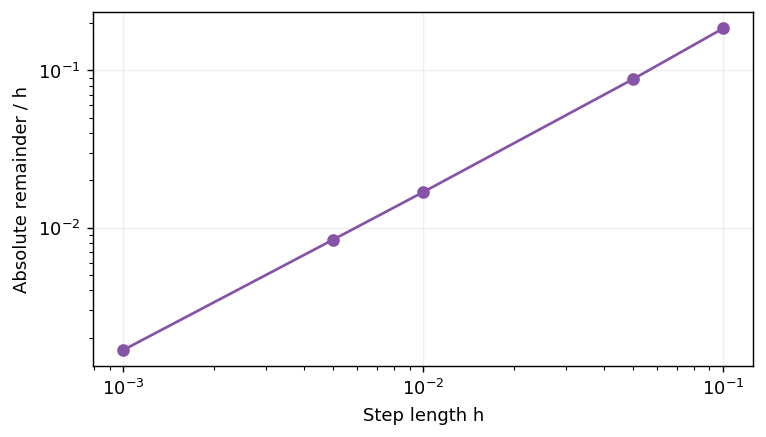

In [7]:
steps = [0.1, 0.05, 0.01, 0.005, 0.001]
ratios = []
for h in steps:
    actual_change = e.loss(theta+h*direction, x, y)-e.loss(theta, x, y)
    linear_change = h*analytic_direction
    ratio = abs(actual_change-linear_change)/h
    ratios.append(ratio)
    print(f"h={h:g}, actual={actual_change:.9f}, linear={linear_change:.9f}, remainder/h={ratio:.9f}")
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.loglog(steps, ratios, "o-", color="#8653A6")
ax.set_xlabel("Step length h"); ax.set_ylabel("Absolute remainder / h")
ax.grid(alpha=.2); fig.tight_layout(); show_figure(fig)

## 7 共享节点必须收集全部路径
s=a+b，t=a-b，z=s²+st。s被使用两次。主点a的贡献为3、0.5、1.5；b的贡献为3、0.5、-1.5。

In [8]:
paths_a = np.array([3., 0.5, 1.5])
paths_b = np.array([3., 0.5, -1.5])
branch_gradient = e.branched_gradient(theta)
branch_fd, _ = e.finite_jacobian(e.branched, theta, 1e-5)
print("z:", e.branched(theta))
print("a三路径:", paths_a, "相加:", paths_a.sum())
print("b三路径:", paths_b, "相加:", paths_b.sum())
print("链式梯度:", branch_gradient)
print("差分梯度:", branch_fd[0])
print("独立展开梯度:", [4*theta[0]+2*theta[1], 2*theta[0]])
assert np.allclose(branch_fd[0], branch_gradient, atol=e.ATOL, rtol=e.RTOL)

z: 3.0
a三路径: [3.  0.5 1.5] 相加: 5.0
b三路径: [ 3.   0.5 -1.5] 相加: 2.0
链式梯度: [5. 2.]
差分梯度: [5. 2.]
独立展开梯度: [np.float64(5.0), np.float64(2.0)]


## 8 差分稳定仍可能没有全微分
f=x³/(x²+y²)，原点定义0。它有偏导(1,0)，每个方向导数也存在，但原点不可微。单位对角方向的真变化率与偏导内积不同。

In [9]:
counter_partials, _ = e.finite_jacobian(e.partial_counterexample, [0., 0.], 0.01)
diagonal = np.array([1., 1.])/np.sqrt(2)
actual = e.directional_difference(e.partial_counterexample, [0., 0.], diagonal, 0.01)
invalid_prediction = counter_partials[0] @ diagonal
print("坐标偏导:", counter_partials[0])
print("实际对角方向导数:", actual)
print("把偏导内积当全导数的错误预测:", invalid_prediction)
print("严格反例：沿(h,h)的绝对余量/位移长度 =", 1/(2*np.sqrt(2)))

坐标偏导: [1. 0.]
实际对角方向导数: 0.35355339059327373
把偏导内积当全导数的错误预测: 0.7071067811865476
严格反例：沿(h,h)的绝对余量/位移长度 = 0.35355339059327373


## 9 零梯度不自动等于最小值
在(6/5,0)一阶项为0，但沿b可以下降。此处用函数值与代数展开判断，不需要Hessian。

In [10]:
stationary = np.array([1.2, 0.])
print("梯度:", e.gradient_chain(stationary, x, y))
print("起点损失:", e.loss(stationary, x, y))
print("只增加b 0.1:", e.loss(stationary+[0., 0.1], x, y))
print("只增加a 0.1:", e.loss(stationary+[0.1, 0.], x, y))

梯度: [-1.11022302e-16  0.00000000e+00]
起点损失: 0.6
只增加b 0.1: 0.5907666666666666
只增加a 0.1: 0.6166666666666667


## 10 定义域保护
log(a-b²)要求a>b²。差分的两侧采样点也必须合法；当前点合法不代表任意步长合法。

In [11]:
log_theta = np.array([2., 0.5])
log_fd, _ = e.finite_jacobian(e.log_gap, log_theta, 1e-5)
log_gradient = np.array([1., -2*log_theta[1]])/(log_theta[0]-log_theta[1]**2)
print("对数梯度 / 差分:", log_gradient, log_fd[0])
try:
    e.finite_jacobian(e.log_gap, [0.26, 0.5], 0.1)
except ValueError as error:
    print("预期拒绝越界采样:", str(error))

对数梯度 / 差分: [ 0.57142857 -0.57142857] [ 0.57142857 -0.57142857]
预期拒绝越界采样: log_gap 定义域要求 a-b²>0


## 11 25点核验与步长扫描
下面运行全部数值审计，但暂不写文件。25个点不是随机样本，也不是一般证明。曲线只显示接受的步长；拒绝不会记成0误差。

固定参数点数: 25
25点梯度差分最大绝对误差: 4.0841530157820216e-10
forward 拒绝步长: [1e-16, 1e-20]
central 拒绝步长: [1e-16, 1e-20]


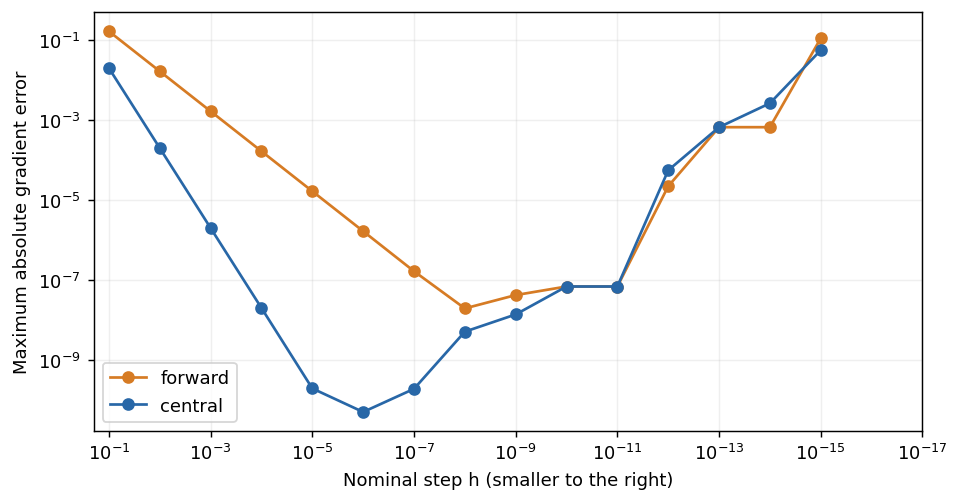

h: 0.01 central: 0.0001999999999976465
h: 1e-06 central: 5.0051851552268545e-11
h: 1e-12 central: 5.558010154038673e-05


In [12]:
report = e.run_all(write_outputs=False)
checks = report["deterministic_grid"]["checks"]
print("固定参数点数:", len(checks))
print("25点梯度差分最大绝对误差:", max(r["gradient_fd_max_abs_error"] for r in checks))
fig, ax = plt.subplots(figsize=(7.5, 4))
for method, color in [("forward", "#D67B24"), ("central", "#2867A7")]:
    accepted = [r for r in report["step_sweep"] if r[method]["status"]=="ok"]
    ax.loglog([r["h"] for r in accepted], [r[method]["max_abs_error"] for r in accepted], "o-", color=color, label=method)
    print(method, "拒绝步长:", [r["h"] for r in report["step_sweep"] if r[method]["status"]=="rejected"])
ax.set_xlim(0.2, 1e-17)
ax.set_xlabel("Nominal step h (smaller to the right)")
ax.set_ylabel("Maximum absolute gradient error")
ax.legend(); ax.grid(alpha=.2); fig.tight_layout(); show_figure(fig)
for row in report["step_sweep"]:
    if row["h"] in [0.01, 1e-6, 1e-12]:
        print("h:", row["h"], "central:", row["central"]["max_abs_error"])

## 12 能运行却不正确的广播
下格先演示NumPy原生广播，再展示受保护接口的拒绝。主目标是3项逐记录误差，不是9项两两误差。

In [13]:
wrong_residual = p-y[:, None]
print("正确残差形状:", (p-y).shape)
print("错误广播形状:", wrong_residual.shape)
print("正确平均平方:", np.mean((p-y)**2))
print("错误平均平方:", np.mean(wrong_residual**2))
try:
    e.loss(theta, x, y[:, None])
except ValueError as error:
    print("接口按契约拒绝:", str(error))
try:
    e.prediction([1, True], x)
except ValueError as error:
    print("混合布尔列表在转换前被拒绝:", str(error))

正确残差形状: (3,)
错误广播形状: (3, 3)
正确平均平方: 0.3958333333333333
错误平均平方: 1.0625
接口按契约拒绝: y 必须是一维且与 x 同形，防止广播改变损失
混合布尔列表在转换前被拒绝: theta 必须是实数标量，不能为布尔、字符串或复数


## 13 保存完整结果
34组边界包括类型、样本轴、目标形状、步长、不可分辨采样、分母溢出、方向、定义域和输出尺寸变化。输出路径相对于本实验目录。

In [14]:
report = e.run_all(write_outputs=True)
e.print_summary(report)
print("边界名称:", report["boundary"]["names"])
print("差分CSV存在:", Path("outputs/finite_difference_sweep.csv").exists())

NumPy: 2.3.5
主点损失 19/48 = 0.3958333333333333
梯度 [-1/6, -5/6] = [-0.16666666666666669, -0.8333333333333334]
预测 Jacobian 形状: [3, 2]
单位方向变化率 -23/30 = -0.7666666666666667
分支例梯度 [5,2] = [5.0, 2.0]
确定性网格点数: 25
边界通过组数: 34
输出文件存在: True
边界名称: ['theta_column', 'theta_row', 'theta_length', 'theta_bool', 'theta_string', 'theta_complex', 'theta_object', 'theta_nan', 'theta_inf', 'x_empty', 'y_column', 'y_length', 'x_mixed_bool', 'object_leaf', 'zero_step', 'negative_step', 'bool_step', 'string_step', 'infinite_step', 'unresolved_step', 'overflow_denominator', 'directional_denominator_overflow', 'directional_sample_overflow', 'branched_gradient_sum_overflow', 'branched_gradient_difference_overflow', 'counterexample_overflow', 'counterexample_underflow_division', 'bad_method', 'zero_direction', 'nonunit_direction', 'domain_point', 'domain_crossing', 'changing_output_shape', 'single_sample_shapes']
差分CSV存在: True


## 结论与继续练习

梯度是按坐标排列的局部系数，不是标量损失；Jacobian按输出行、输入列组织。完整路径上相乘，多条路径间相加，外层导数在中间输出处求值。中心差分核验实现，不能替代定义域与可微性条件。

请按lab.md完成一页实验记录，并练习answers.md的17题。Notebook在新Python进程的真实进程内内核中顺序执行并保存输出；浏览器Jupyter UI、外进程socket传输、学习者本机Anaconda与其他操作系统未测试。